# Data validation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pvforecast import preprocessing
from pvforecast.config import (
    PERIOD_END,
    PERIOD_START,
    PV_RAW,
    PV_RAW_HOURLY,
    RADIATION_VARS,
    WEATHER_RAW,
)

pd.set_option("display.width", 120)

## PV feed-in: quarter-hour raw data

In [2]:
raw = preprocessing.load_raw_quarterhour(PV_RAW)

print(f"Zeitraum: {raw.index.min()} bis {raw.index.max()}")
print(f"Zeilen: {len(raw):,}")
print(f"NaN: {raw['pv_mwh'].isna().sum()}")
print(f"Duplikate im Index: {raw.index.duplicated().sum()}")

Zeitraum: 2014-12-28 23:00:00+00:00 bis 2026-06-21 21:45:00+00:00
Zeilen: 402,524
NaN: 607
Duplikate im Index: 0


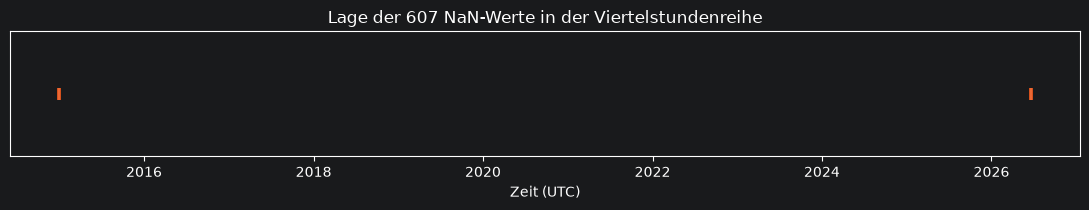

Erster gültiger Wert: 2014-12-31 23:00:00+00:00
Letzter gültiger Wert: 2026-06-18 14:00:00+00:00


In [3]:
# NaN only at the edges of the recording means the series itself is complete
mask = raw["pv_mwh"].isna()

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.scatter(raw.index[mask], [1] * mask.sum(), marker="|", s=80, color="#eb6834")
ax.set_yticks([])
ax.set_xlabel("Zeit (UTC)")
ax.set_title(f"Lage der {mask.sum()} NaN-Werte in der Viertelstundenreihe")
fig.tight_layout()
plt.show()

valid = raw.dropna()
print(f"Erster gültiger Wert: {valid.index.min()}")
print(f"Letzter gültiger Wert: {valid.index.max()}")

## Aggregation to hourly

Energy in MWh is summed; an hour with fewer than four quarters becomes NaN.

In [4]:
hourly = preprocessing.build_hourly_series(PV_RAW)

print(f"Zeitraum: {PERIOD_START} bis {PERIOD_END}")
print(f"Stunden: {len(hourly):,}")
print(f"NaN nach dem Schnitt: {hourly['pv_mwh'].isna().sum()}")

Zeitraum: 2014-12-31 23:00 bis 2025-12-31 23:00
Stunden: 96,433
NaN nach dem Schnitt: 0


## Validation against SMARD's own hourly series

SMARD publishes an hourly series of its own. If our aggregation is right, the two
have to agree to rounding.

In [5]:
smard = preprocessing.load_raw_quarterhour(PV_RAW_HOURLY).squeeze()

both = pd.concat(
    [hourly["pv_mwh"].rename("eigen"), smard.rename("smard")], axis=1
).dropna()
diff = (both["eigen"] - both["smard"]).abs()

print(f"Verglichene Stunden: {len(both):,}")
print(f"Maximale Abweichung: {diff.max():.4f} MWh")
print(f"Relativ zum Maximalwert: {diff.max() / both['smard'].max():.1e}")

Verglichene Stunden: 96,433
Maximale Abweichung: 0.0200 MWh
Relativ zum Maximalwert: 3.8e-07


/var/folders/yh/lkk7g31x745fw31sqm8dtqj40000gn/T/ipykernel_10682/1932695712.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  both = pd.concat(


## Time grid and daylight saving

In [6]:
# UTC has no DST, so the hourly grid is regular and free of duplicates
full = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h")

print(f"Fehlende Stunden im Raster: {len(full.difference(hourly.index))}")
print(f"Duplikate im UTC-Index: {hourly.index.duplicated().sum()}")
local = hourly.index[:3].tz_convert("Europe/Berlin")
print(f"Lokalzeit nur für Anzeige: {local.tolist()}")

Fehlende Stunden im Raster: 0
Duplikate im UTC-Index: 0
Lokalzeit nur für Anzeige: [Timestamp('2015-01-01 00:00:00+0100', tz='Europe/Berlin'), Timestamp('2015-01-01 01:00:00+0100', tz='Europe/Berlin'), Timestamp('2015-01-01 02:00:00+0100', tz='Europe/Berlin')]


In [7]:
# Exact zeros should sit at night only; the maximum should be a summer midday
zeros = hourly[hourly["pv_mwh"] == 0]

print(f"Exakte Nullen: {len(zeros)}  |  negative Werte: {(hourly['pv_mwh'] < 0).sum()}")
print("Nullen je UTC-Stunde:")
print(zeros.index.hour.value_counts().sort_index().to_string())
print(f"\nMaximum: {hourly['pv_mwh'].idxmax()} mit {hourly['pv_mwh'].max():,.0f} MWh/h")

Exakte Nullen: 7770  |  negative Werte: 0
Nullen je UTC-Stunde:
time
0     830
1     793
2     635
3     459
4     308
5     204
6      26
16     31
17    238
18    385
19    541
20    751
21    859
22    868
23    842

Maximum: 2025-06-20 10:00:00+00:00 mit 52,132 MWh/h


## Weather: five ERA5 cells

The pipeline averages five grid cells. Each has to cover every hour, otherwise the
spatial mean would silently weight the sites unevenly.

In [8]:
weather = preprocessing.load_weather(WEATHER_RAW)

print(f"Standorte: {sorted(weather['site'].unique())}")
print(f"Zeilen je Standort:\n{weather['site'].value_counts().to_string()}")
print(f"\nNaN je Spalte:\n{weather.isna().sum().to_string()}")

Standorte: ['nord', 'ost', 'suedost', 'suedwest', 'west']
Zeilen je Standort:
site
nord        96504
ost         96504
west        96504
suedwest    96504
suedost     96504

NaN je Spalte:
time                    0
site                    0
shortwave_radiation     0
direct_radiation        0
diffuse_radiation       0
temperature_2m          0
cloud_cover             0
relative_humidity_2m    0
wind_speed_10m          0


In [9]:
# Radiation is a backward mean over the past hour, SMARD labels forward -> shift
aligned = preprocessing.align_radiation_labels(weather)
national = preprocessing.spatial_mean(aligned)

ghi = national["shortwave_radiation"]
night = ghi[ghi.index.hour.isin([23, 0, 1, 2])]

print(f"Nacht-GHI: min {night.min():.2f}, max {night.max():.2f} W/m²")
print(f"Negative GHI-Werte: {(ghi < 0).sum()}")
print(national[RADIATION_VARS].describe().round(1).to_string())

Nacht-GHI: min 0.00, max 0.00 W/m²
Negative GHI-Werte: 0
       shortwave_radiation  direct_radiation  diffuse_radiation
count              96503.0           96503.0            96503.0
mean                 132.1              78.0               54.1
std                  195.4             134.7               71.4
min                    0.0               0.0                0.0
25%                    0.0               0.0                0.0
50%                    7.0               1.0                5.4
75%                  214.2             102.4              101.0
max                  882.0             749.0              338.8


In [10]:
# The join must not lose a single PV hour
joined = preprocessing.join_pv_weather(hourly, national)

print(f"Stunden: {len(joined):,}  |  Spalten: {joined.shape[1]}")
print(f"NaN gesamt: {int(joined.isna().sum().sum())}")

Stunden: 96,433  |  Spalten: 8
NaN gesamt: 0


## Feed-in and irradiance over five days

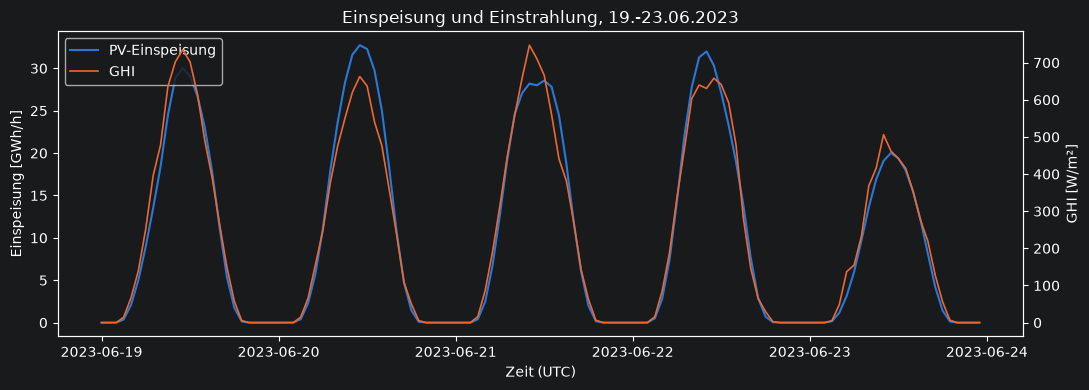

In [11]:
window = joined.loc["2023-06-19":"2023-06-23"]

fig, ax_pv = plt.subplots(figsize=(11, 4))
ax_pv.plot(
    window.index, window["pv_mwh"] / 1000, color="#2a78d6", label="PV-Einspeisung"
)
ax_pv.set_ylabel("Einspeisung [GWh/h]")
ax_pv.set_xlabel("Zeit (UTC)")

ax_ghi = ax_pv.twinx()
ax_ghi.plot(
    window.index, window["shortwave_radiation"], color="#eb6834", lw=1.2, label="GHI"
)
ax_ghi.set_ylabel("GHI [W/m²]")
ax_ghi.grid(False)

handles = ax_pv.get_legend_handles_labels()[0] + ax_ghi.get_legend_handles_labels()[0]
ax_pv.legend(handles, ["PV-Einspeisung", "GHI"], loc="upper left")
ax_pv.set_title("Einspeisung und Einstrahlung, 19.-23.06.2023")
fig.tight_layout()
plt.show()